---  Random Forest Report ---
              precision    recall  f1-score   support

      Benign       0.90      0.96      0.93        72
   Malignant       0.92      0.81      0.86        42

    accuracy                           0.90       114
   macro avg       0.91      0.88      0.89       114
weighted avg       0.90      0.90      0.90       114


---  XGBoost Report ---
              precision    recall  f1-score   support

      Benign       0.94      0.93      0.94        72
   Malignant       0.88      0.90      0.89        42

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



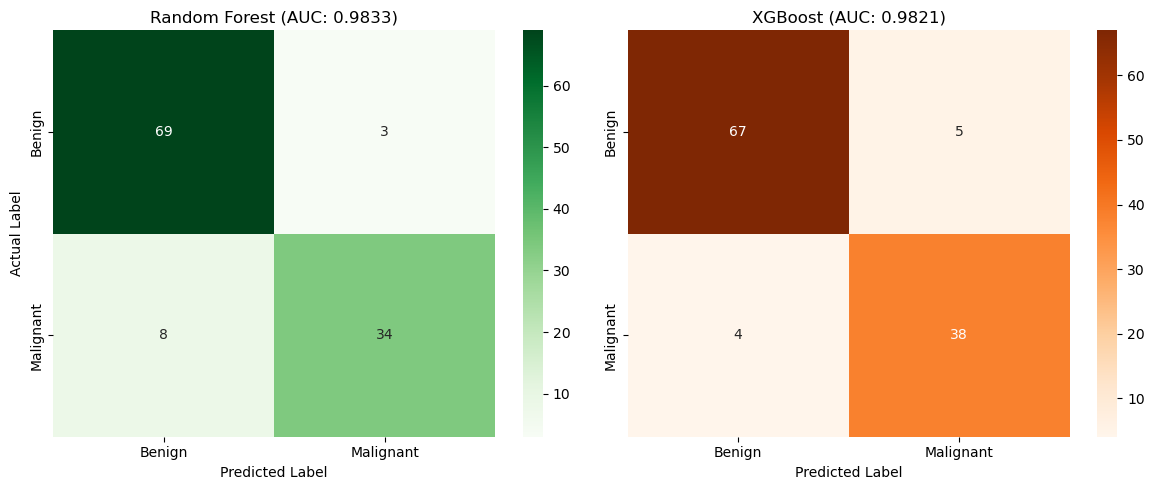

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# 이전 단계 데이터 세팅 유지
cancer = load_breast_cancer()
df = pd.DataFrame(data=cancer.data, columns=cancer.feature_names)
y = np.where(cancer.target == 0, 1, 0)
X = df[['mean area', 'mean concavity', 'mean symmetry']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#  Random Forest 구축 (집단 지성)
# class_weight를 통해 악성 종양에 5배 민감하게 반응하도록 숲을 조성
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight={0: 1, 1: 5})
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# XGBoost 구축 (연쇄 오차 교정)
# scale_pos_weight로 극단적인 재현율 방어선 구축 (양성/악성 비율 고려 + 가중치)
xgb_model = xgb.XGBClassifier(
    n_estimators=200, 
    random_state=42, 
    scale_pos_weight=5, 
    #use_label_encoder=False, 
    eval_metric='logloss'
)
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

# 4. 앙상블 모델 ROC-AUC 평가 및 시각화
rf_auc = roc_auc_score(y_test, y_prob_rf)
xgb_auc = roc_auc_score(y_test, y_prob_xgb)

print("---  Random Forest Report ---")
print(classification_report(y_test, y_pred_rf, target_names=['Benign', 'Malignant']))
print("\n---  XGBoost Report ---")
print(classification_report(y_test, y_pred_xgb, target_names=['Benign', 'Malignant']))

# Confusion Matrix 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
axes[0].set_title(f'Random Forest (AUC: {rf_auc:.4f})')
axes[0].set_ylabel('Actual Label')
axes[0].set_xlabel('Predicted Label')

sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
axes[1].set_title(f'XGBoost (AUC: {xgb_auc:.4f})')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('./images/ensemble_comparison.png', dpi=300, bbox_inches='tight')
plt.show()